# Libraries

In [70]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating INQUIRE Benchmarks 

Here we will evaluate the raw query metrics returned by INQUIRE_benchmark. These raw metrics were calculated using [INQUIRE-Benchmark-small](https://huggingface.co/datasets/sagecontinuum/INQUIRE-Benchmark-small) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), Triton's [gemma3](https://huggingface.co/google/gemma-3-27b-it) caption model, and set to **response_limit=50**. This means it will return up to 50 images. This was configured this way because INQUIRE uses the top 50 as well to benchmark models.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.
>NOTE: INQUIRE also provides a [leaderboard](https://inquire-benchmark.github.io/). This is helpful for comparing our results.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and Triton's `gemma3` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.4 → 40% dense / 60% keyword). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.

Here were the Hyperparameters used for the image search:

In [71]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'query_alpha': 0.4, 'clip_alpha': 0.7, 'enabl...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
3,embed_caption,True,bool
4,embed_image,True,bool
5,enable_bm25,True,bool
6,enable_caption_generation,True,bool
7,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
8,hnsw_dynamicEfMax,500,int
9,hnsw_dynamicEfMin,200,int


## Query and Image Collection Process

This explanation was grabbed from the [INQUIRE paper](https://arxiv.org/abs/2411.02537) so that we can better understand the results in further sections

### Query Collection
To ensure that INQUIRE comprises text queries that are relevant to scientists,
we conducted interviews with individuals across different ecological and environmental domains -
including experts in ornithology, marine biology, entomology, and forestry. Further queries were
sourced from reviews of academic literature in ecology. We retained only queries that (1) could be discerned from images
alone, (2) were feasible to comprehensively label over the entire iNat24 dataset, and (3) were of
interest to domain experts.

### Image Annotation
All image annotations were performed by a small set of individuals whose
interest and familiarity with wildlife image collections enabled them to provide accurate labels for
challenging queries. Annotators were instructed to label all candidate images as either relevant (i.e.,
positive match) or not relevant (i.e., negative match) to a query, and to mark an image as not relevant
if there was reasonable doubt. To allow for comprehensive labeling, where applicable, iNat24 species
labels were used to narrow down the search to a sufficiently small size to label all relevant images for
the query of interest. For queries in which species labels could not be used, labeling was performed
over the top CLIP ViT-H-14 retrievals alone. In this case, the resulting annotations were only
kept if we were certain that this labeling captured the vast majority of positives, including labeling
until at least 100 consecutive retrievals were not relevant. Queries that were deemed
too easy, not comprehensively labeled, or otherwise not possible to label were excluded from our
benchmark. In total, this process resulted in 250 queries which involved labeling 194,334 images, of
which 32,696 were relevant to their query.

### Query Categories
Each query belongs to one of four supercategories (appearance, behavior,
context, or species), and further into one of sixteen fine-grained categories (e.g., Animal Structures
and Habitats). We also note
queries that use scientific terminology, words typically used only within scientific contexts (e.g., “A
godwit performing distal rhynchokinesis”).

### Data Split
We divide all queries into 50 validation and 200 test queries using a random split,
stratified by category.

## Query Coverage

Queries cover a range of topics and a organism taxonomies:

![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_iconic_groups.png?raw=1)
![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_categories.png?raw=1)

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries created by the INQUIRE authors.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: Measures whether at least one relevant result appears in the results. To get hit rate we take the mean of the hit column.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP ViT-H-14 was used by the INQUIRE authors to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rerank_score_reciprocal_rank**: The reciprocal rank of the rerank scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on rerank_score column.
- **clip_score_reciprocal_rank**: The reciprocal rank of the clip scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on clip_score column.
- **category**: The category given to the query by the INQUIRE authors. (ex; Defensive and Survival Behaviors)
- **supercategory**: The supercategory given the the query by the INQUIRE authors. (ex; Behavior)
- **iconic_group**: The iconic group given to the query by the INQUIRE authors. (ex; Mammals)

NOTE: k=response_limit


In [72]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg colums
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG', 
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,diversity,NDCG,clip_NDCG,rr,clip_rr,category,supercategory,iconic_group
0,66,Mushrooms growing in a fairy ring formation,50,20,30,5,45,0.40,0.10,0.625000,1,0.406334,0.776121,0.792952,1.000000,1.00,Miscellaneous Context,Context,Fungi
1,189,puffins carrying food,50,23,27,1,49,0.46,0.02,0.125000,1,0.376728,0.649983,0.966103,1.000000,1.00,Feeding and Hydration,Behavior,Birds
2,142,cross orbweaver,50,1,49,0,50,0.02,0.00,0.000000,0,0.446596,0.512367,0.710247,0.100000,1.00,Species ID,Species,Arachnids
3,98,a hermit crab using plastic waste as a shell,50,45,5,3,47,0.90,0.06,1.000000,1,0.240673,0.682436,0.514791,1.000000,0.50,Human Impact,Context,Animalia
4,83,Tagged swan,50,47,3,13,37,0.94,0.26,0.433333,1,0.264904,0.998751,0.995708,1.000000,1.00,Tracking and Identification,Appearance,Birds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,0,A By-the-Wind Sailor washed up on a beach,50,16,34,0,50,0.32,0.00,0.000000,0,0.315923,0.454032,0.640689,0.055556,0.25,Health and Disease,Appearance,Animalia
156,126,bullhead shark egg case,50,2,48,0,50,0.04,0.00,0.000000,0,0.410293,0.443195,0.642541,0.125000,1.00,Life Cycle and Development,Appearance,Fish
157,47,Haliaeetus eagles in aerial cartwheeling fligh...,50,21,29,1,49,0.42,0.02,1.000000,1,0.256200,0.321191,0.403151,0.100000,0.20,"Mating, Courtship, Reproduction",Behavior,Birds
158,152,feral cat with prey,50,45,5,13,37,0.90,0.26,0.928571,1,0.338444,0.857191,0.876951,1.000000,1.00,Feeding and Hydration,Behavior,Mammals


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [73]:
render_dlq_analysis(Path("."))


DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [74]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()


# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")


total_images: 8000
correctly_returned: 4730
incorrectly_returned: 3270
relevant_images: 1266
non_relevant_images: 6734
accuracy: 0.59125
precision: 0.15825
recall: 0.45307615923489364
hit_rate: 0.85
NDCG: 0.6949286091493609
clip_NDCG: 0.7160284669939466
mrr: 0.6830329163634417
clip_mrr: 0.68813435075127
diversity: 0.2811478217399163

Insights:
The system returned a total of 4730 correct images out of 8000 total images returned.
The accuracy of the system is 0.5913, indicating that 59.13% of the returned images correctly matched with the query.
The precision of the system is 0.1583, indicating that 15.82% of the total images returned were relevant images.
The recall of the system is 0.4531, indicating that 45.31% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.8500, indicating that 85.00% of the total queries processed had at least one relevant image.
The NDCG score is 0.6949, and the Clip NDCG score is 0.7160, indicating the ranking quality of

## Metrics based on Supercategory

Now, we will evaluate queries based on their categories.


In [75]:
# Group by category and calculate the sum/mean of each metric
supercategory_metrics = df.groupby('supercategory').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

supercategory_metrics

,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Appearance,2600,1272,1328,278,2322,0.489231,0.106923,0.363728,0.750000,0.630470,0.691112,0.572363,0.625715,0.295577
1,Behavior,2950,1992,958,522,2428,0.675254,0.176949,0.517478,0.915254,0.729154,0.749854,0.726564,0.749108,0.267237
2,Context,2150,1291,859,408,1742,0.600465,0.189767,0.486784,0.883721,0.724873,0.709687,0.755545,0.694856,0.285659
3,Species,300,175,125,58,242,0.583333,0.193333,0.352563,0.833333,0.702423,0.644799,0.694444,0.581349,0.260553


### Accuracy

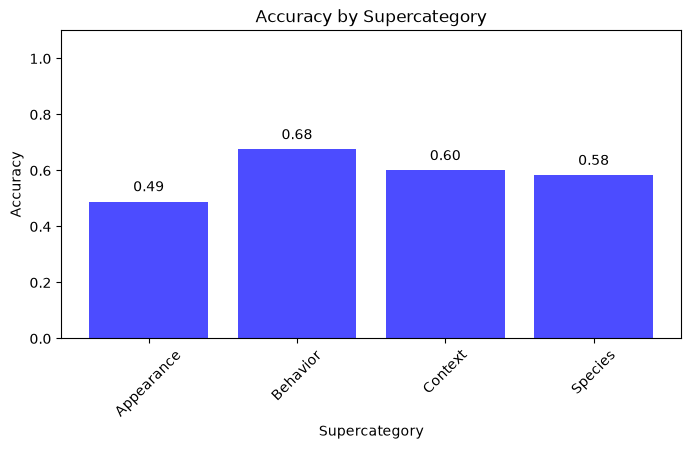

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Supercategory")
ax.set_title("Accuracy by Supercategory")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

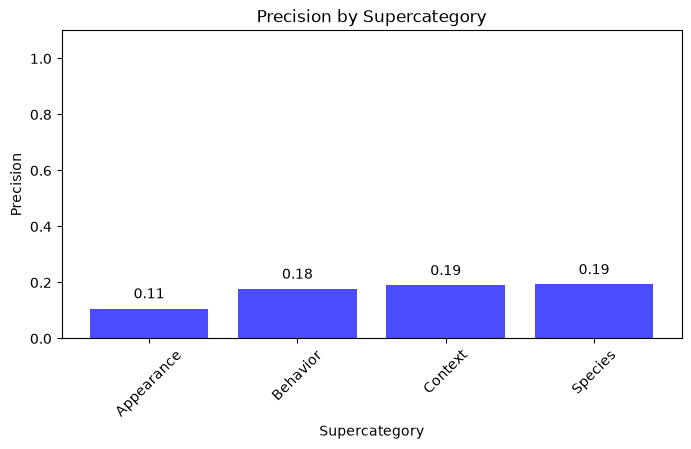

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Supercategory")
ax.set_title("Precision by Supercategory")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

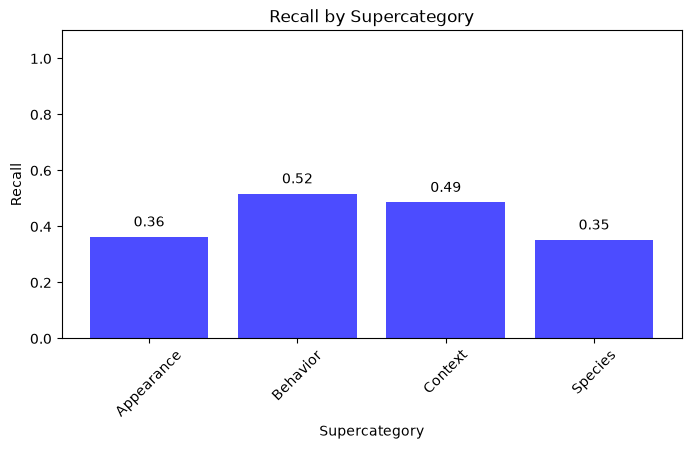

In [78]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Supercategory")
ax.set_title("Recall by Supercategory")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

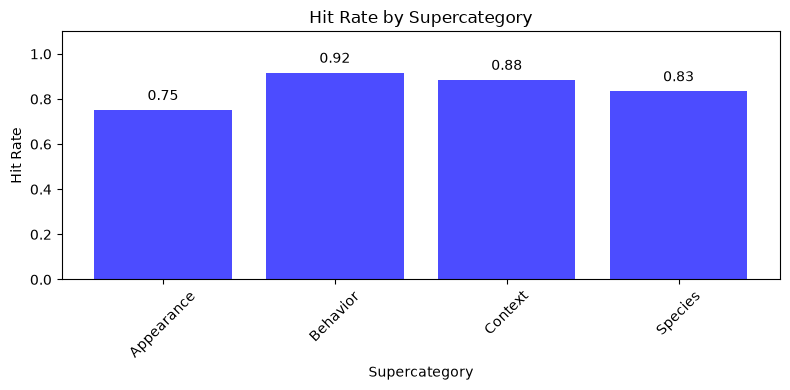

In [79]:
# Hit Rate by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Supercategory")
ax.set_title("Hit Rate by Supercategory")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


Text(0.5, 1.0, 'Diversity by Supercategory')

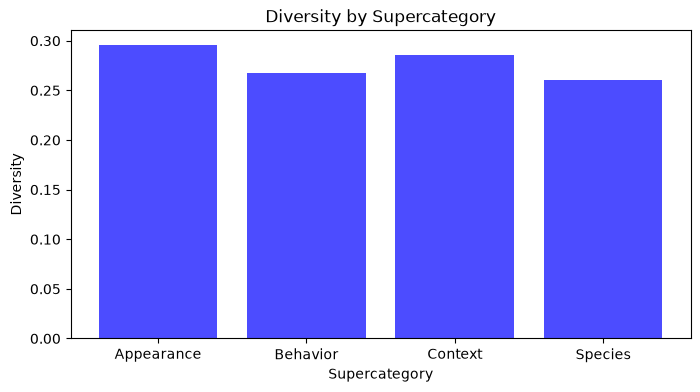

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['diversity'], color="blue", alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Supercategory")
ax.set_title("Diversity by Supercategory")

### NDCG

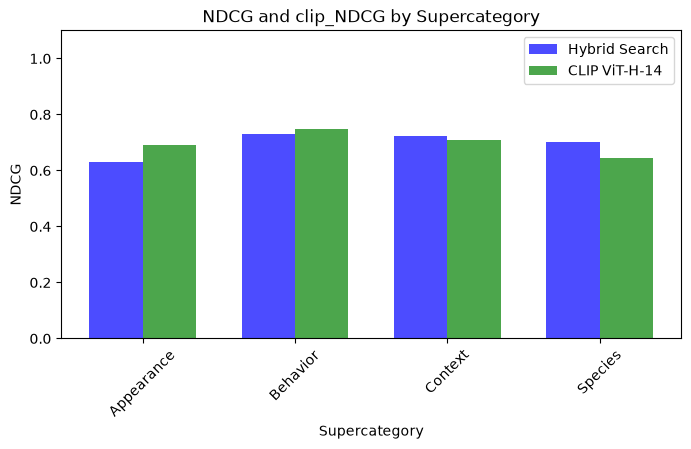

In [81]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Supercategory")
ax.set_title("NDCG and clip_NDCG by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

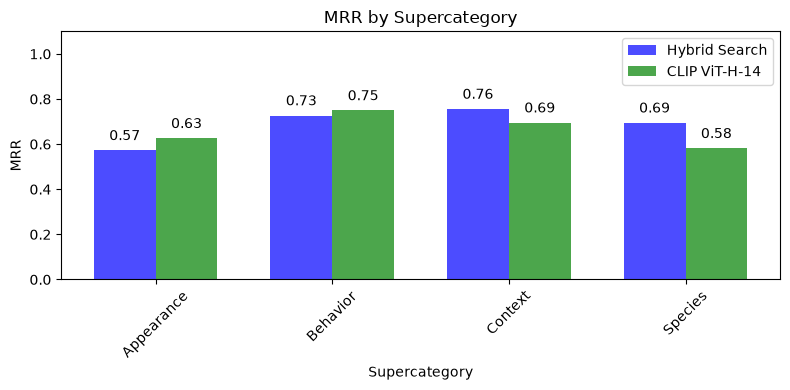

In [82]:
# MRR and clip_MRR by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Supercategory")
ax.set_title("MRR by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Metrics based on Category

In [83]:
# Group by category and calculate the sum/mean of each metric while keeping supercategory
category_metrics = df.groupby(['category']).agg({
    'supercategory': 'first',  # Assuming each category has a single supercategory
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).sort_values(by="supercategory").reset_index()

category_metrics

,category,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Health and Disease,Appearance,600,360,240,100,500,0.600000,0.166667,0.324100,0.750000,0.604108,0.740088,0.516156,0.659722,0.263238
1,Life Cycle and Development,Appearance,750,278,472,43,707,0.370667,0.057333,0.235171,0.600000,0.527224,0.594570,0.408333,0.542927,0.297578
2,Sex identification,Appearance,400,182,218,29,371,0.455000,0.072500,0.226553,0.625000,0.578841,0.622044,0.479980,0.464881,0.330109
3,Tracking and Identification,Appearance,400,196,204,62,338,0.490000,0.155000,0.476917,1.000000,0.836426,0.944634,0.937500,1.000000,0.321638
4,Unique appearances or morphs,Appearance,450,256,194,44,406,0.568889,0.097778,0.652150,0.888889,0.700515,0.622754,0.678241,0.528620,0.281499
5,Cooperative and Social Behaviors,Behavior,900,664,236,188,712,0.737778,0.208889,0.517594,0.944444,0.774190,0.778681,0.782407,0.789352,0.253591
6,Defensive and Survival Behaviors,Behavior,400,233,167,58,342,0.582500,0.145000,0.366298,0.750000,0.658741,0.700158,0.511520,0.786932,0.298264
7,Feeding and Hydration,Behavior,850,566,284,88,762,0.665882,0.103529,0.520529,0.882353,0.669166,0.739851,0.676969,0.715309,0.281121
8,"Mating, Courtship, Reproduction",Behavior,550,354,196,97,453,0.643636,0.176364,0.602287,1.000000,0.731826,0.711544,0.789394,0.715152,0.260668
9,Miscellaneous Behavior,Behavior,250,175,75,91,159,0.700000,0.364000,0.561995,1.000000,0.877759,0.843885,0.900000,0.733333,0.233970


In [84]:
# Define colors for each supercategory
supercategory_colors = {
    "Context": "red",
    "Behavior": "green",
    "Appearance": "blue",
    "Species": "orange"
}

# Assign colors based on supercategory
colors = [supercategory_colors[sc] for sc in category_metrics['supercategory']]

# Bar width
bar_width = 0.35
x = np.arange(len(category_metrics['category']))

### Accuracy

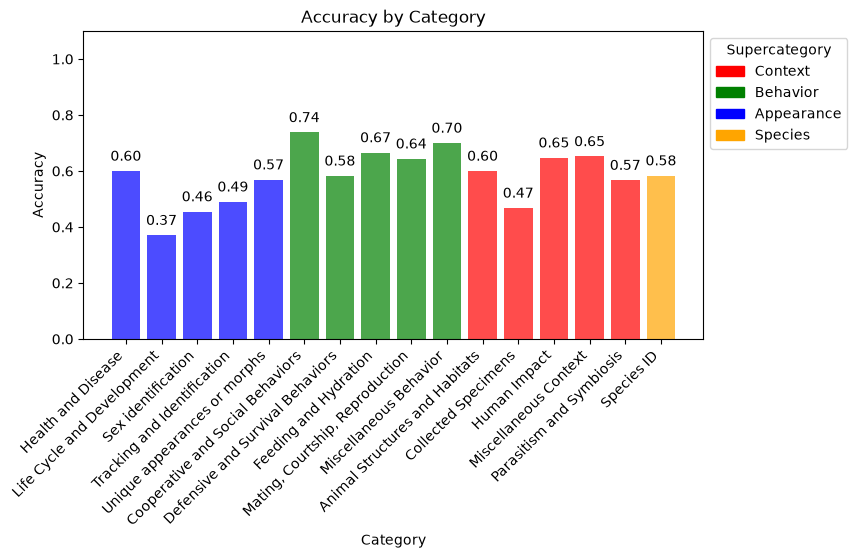

In [85]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['accuracy'], color=colors, alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Category")
ax.set_title("Accuracy by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Precision

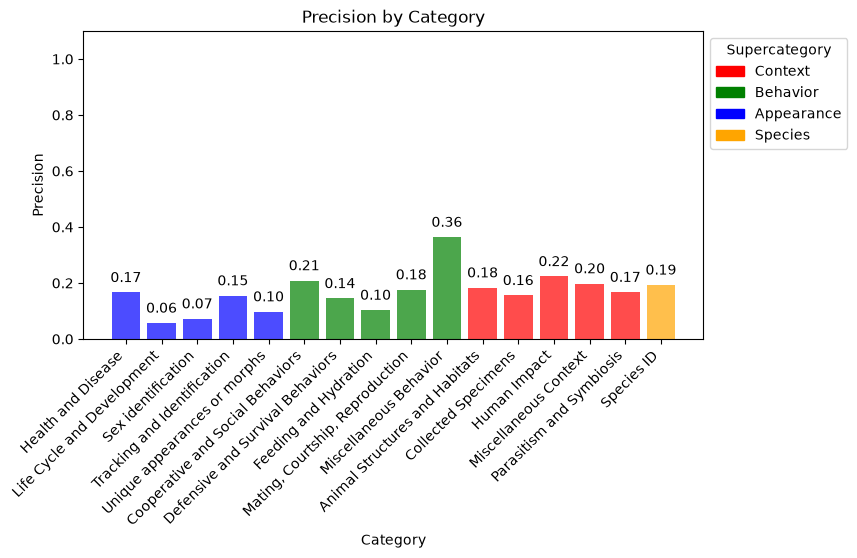

In [86]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['precision'], color=colors, alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Category")
ax.set_title("Precision by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Recall

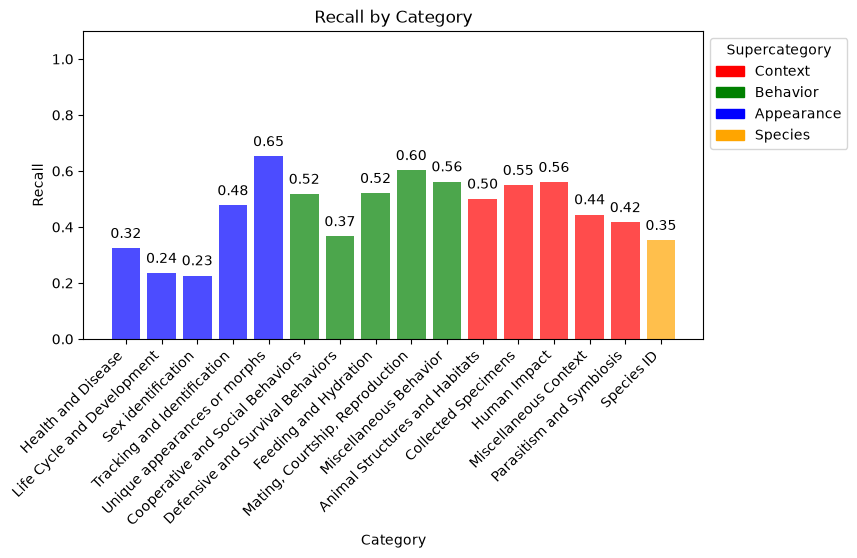

In [87]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['recall'], color=colors, alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Category")
ax.set_title("Recall by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Hit Rate

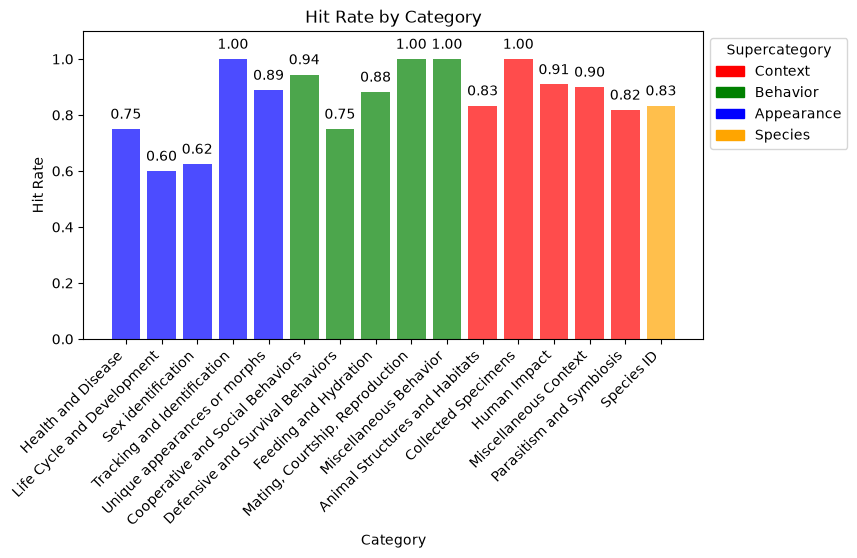

In [88]:
# Hit Rate by Category
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['hit'], color=colors, alpha=0.7)

ax.set_ylabel("Hit Rate")
ax.set_xlabel("Category")
ax.set_title("Hit Rate by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Diversity

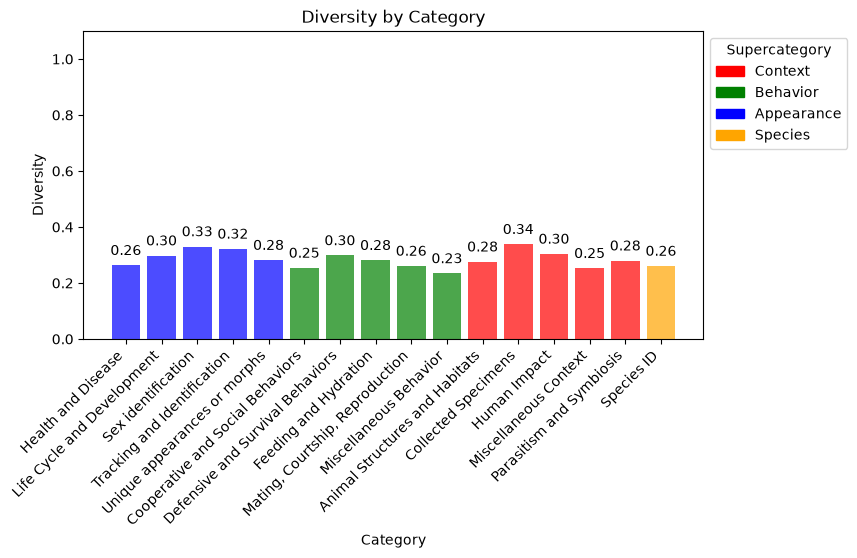

In [89]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['diversity'], color=colors, alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Category")
ax.set_title("Diversity by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### NDCG

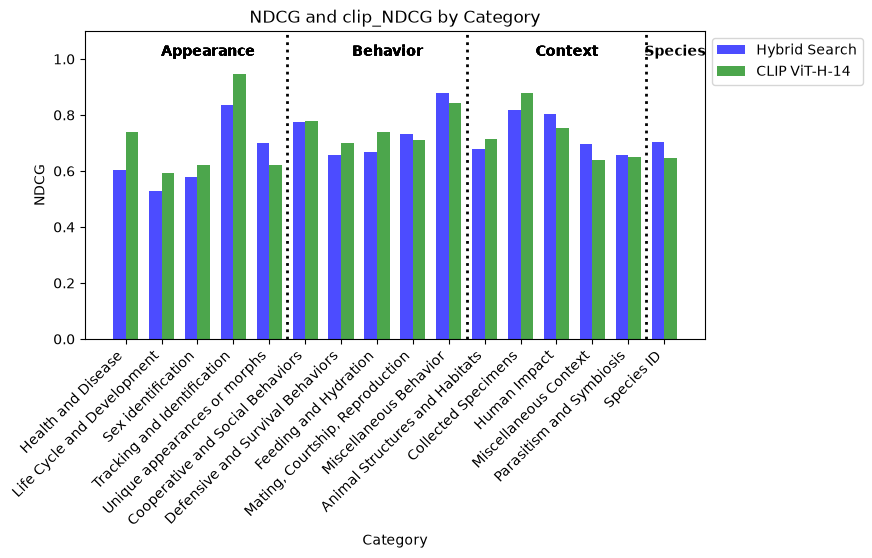

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create side-by-side bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, category_metrics['NDCG'], width=bar_width,
               label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_NDCG'], width=bar_width,
               label="CLIP ViT-H-14", color="green", alpha=0.7)

# Set x-ticks and category labels
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# add labels and titles
ax.set_ylabel("NDCG")
ax.set_xlabel("Category")
ax.set_title("NDCG and clip_NDCG by Category")
ax.set_ylim(0, 1.1)  # Increase top limit to make room for supercategory labels
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Add dotted vertical lines between supercategory groups
supercats = category_metrics['supercategory'].values
for i in range(1, len(supercats)):
    if supercats[i] != supercats[i-1]:
        # Place line halfway between bars at index i-0.5
        ax.axvline(x=i - 0.5, color='black', linestyle=':', linewidth=2)

# Add supercategory labels above the groups
for supercat in category_metrics['supercategory']:
    # Find indices for current supercategory
    indices = np.where(category_metrics['supercategory'] == supercat)[0]
    # Calculate the center position for the group
    center_x = ((indices[0] + indices[-1]) / 2) + 0.3
    # Add the supercategory label above the bars
    ax.text(center_x, 1.0, supercat, ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.show()

### MRR

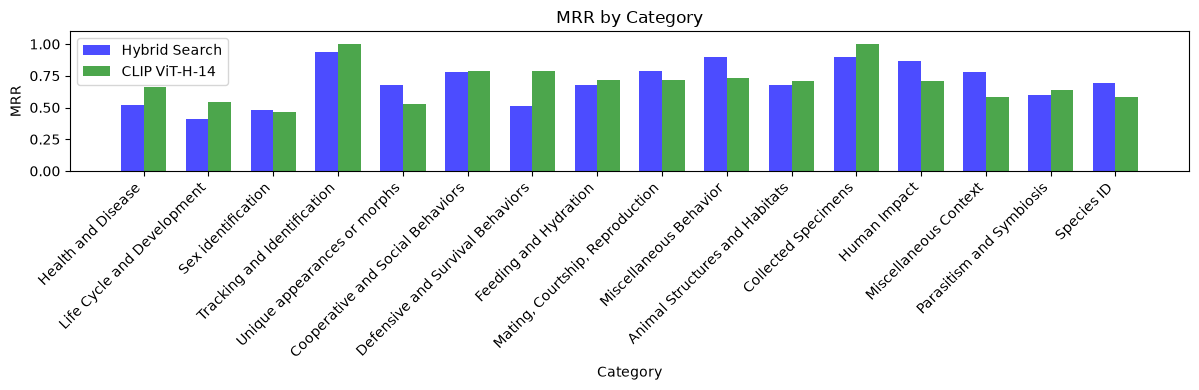

In [91]:
# MRR and clip_MRR by Category
fig, ax = plt.subplots(figsize=(12, 4))
bar_width = 0.35
x = np.arange(len(category_metrics['category']))
bars1 = ax.bar(x - bar_width/2, category_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Category")
ax.set_title("MRR by Category")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Metrics based on Iconic Group

In [92]:
# Group by iconic_group and calculate the sum/mean of each metric
iconic_metrics = df.groupby(['iconic_group']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

iconic_metrics

,iconic_group,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Amphibians,200,135,65,31,169,0.675000,0.155000,0.605186,1.000000,0.603905,0.629004,0.458333,0.583333,0.279011
1,Animalia,150,107,43,16,134,0.713333,0.106667,0.464646,0.666667,0.648105,0.598931,0.685185,0.333333,0.239917
2,Arachnids,350,241,109,42,308,0.688571,0.120000,0.388095,0.571429,0.523237,0.598258,0.372953,0.607143,0.245248
3,Birds,2000,1218,782,284,1716,0.609000,0.142000,0.475373,0.900000,0.705838,0.764907,0.739899,0.812273,0.302398
4,Combo,50,48,2,25,25,0.960000,0.500000,0.892857,1.000000,0.934175,0.957623,1.000000,1.000000,0.223370
5,Fish,350,230,120,58,292,0.657143,0.165714,0.364414,0.857143,0.644967,0.642537,0.574405,0.624150,0.245972
6,Fungi,300,128,172,52,248,0.426667,0.173333,0.413367,1.000000,0.780337,0.697174,0.854167,0.594517,0.300464
7,Insects,1250,495,755,109,1141,0.396000,0.087200,0.318583,0.640000,0.587125,0.637193,0.496918,0.516588,0.295455
8,Mammals,2400,1576,824,479,1921,0.656667,0.199583,0.541326,0.979167,0.788002,0.779699,0.816667,0.784722,0.275399
9,Mollusks,200,90,110,29,171,0.450000,0.145000,0.220789,0.750000,0.692719,0.688862,0.645833,0.583333,0.263293


In [93]:
# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

### Accuracy

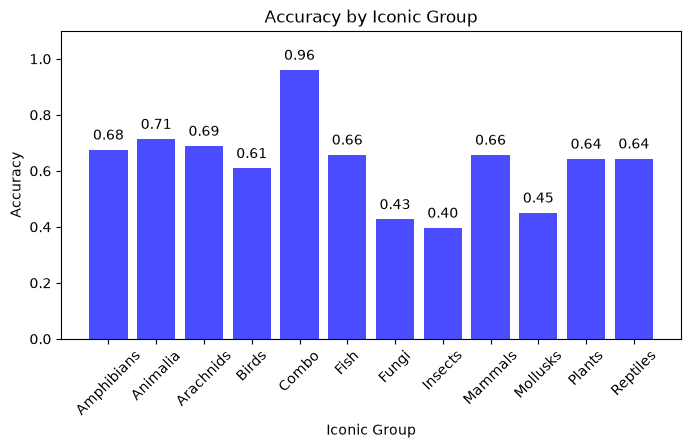

In [94]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Iconic Group")
ax.set_title("Accuracy by Iconic Group")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

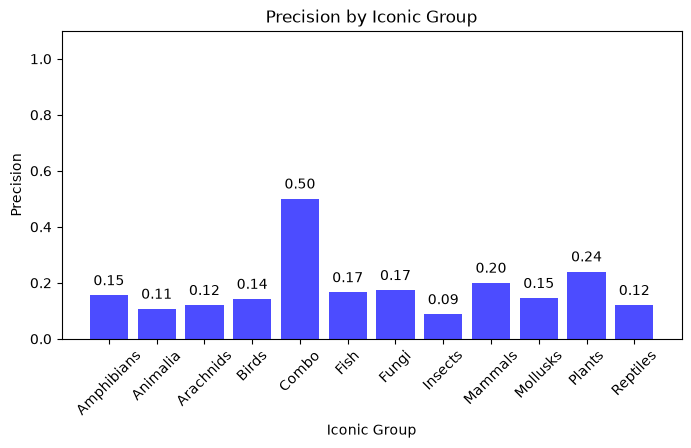

In [95]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Iconic Group")
ax.set_title("Precision by Iconic Group")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

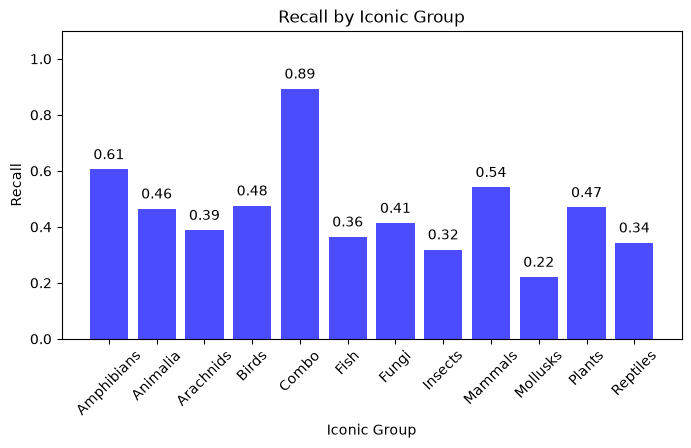

In [96]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Iconic Group")
ax.set_title("Recall by Iconic Group")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

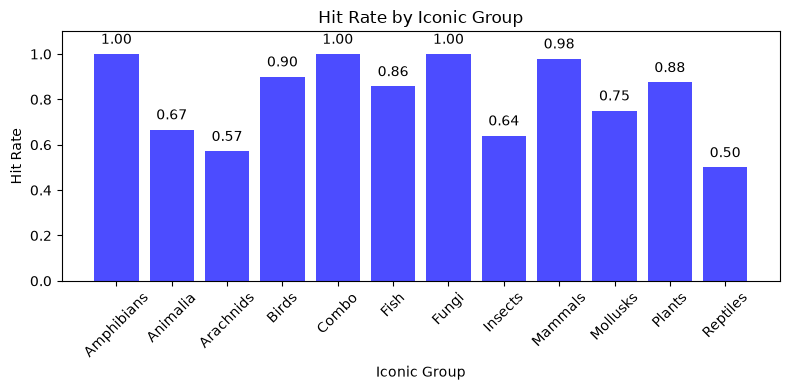

In [97]:
# Hit Rate by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Iconic Group")
ax.set_title("Hit Rate by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


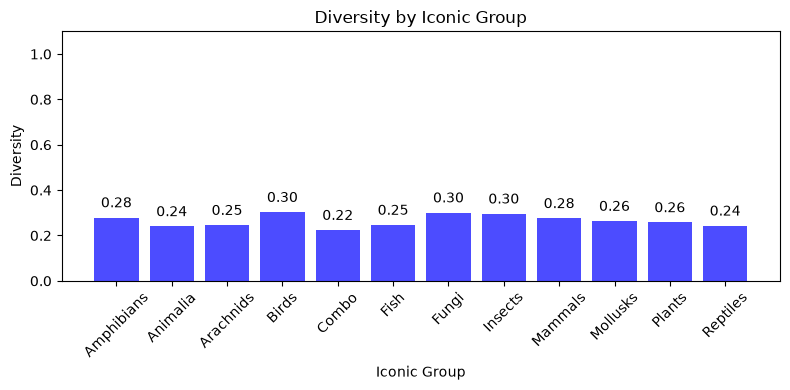

In [98]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['diversity'], color="blue", alpha=0.7)
ax.set_ylabel("Diversity")
ax.set_xlabel("Iconic Group")
ax.set_title("Diversity by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### NDCG

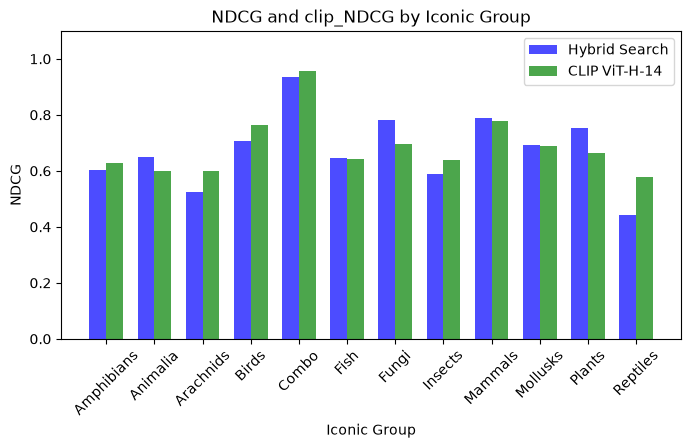

In [99]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, iconic_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Iconic Group")
ax.set_title("NDCG and clip_NDCG by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

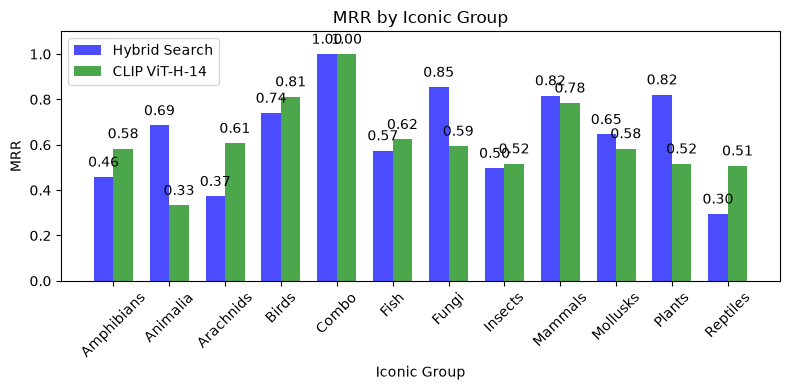

In [100]:
# MRR and clip_MRR by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))
bars1 = ax.bar(x - bar_width/2, iconic_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Iconic Group")
ax.set_title("MRR by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Displaying Metrics used in Leaderboard

Here we will show the metrics used in [INQUIRE's leaderboard](https://inquire-benchmark.github.io/) to be able to see how our Hybrid Search is doing when compared to their leaderboard.

In [101]:
ldboard = {
    "Method": "Hybrid Search",
    "Overall": overall_metrics['precision'],
    "Appearance": supercategory_metrics[supercategory_metrics['supercategory']== 'Appearance']['precision'][0],
    "Behavior": supercategory_metrics[supercategory_metrics['supercategory']== 'Behavior']['precision'][1],
    "Context": supercategory_metrics[supercategory_metrics['supercategory']== 'Context']['precision'][2],
    "Species": supercategory_metrics[supercategory_metrics['supercategory']== 'Species']['precision'][3]

}
# Convert the dictionary to a DataFrame
ldboard_df = pd.DataFrame([ldboard])
ldboard_df

,Method,Overall,Appearance,Behavior,Context,Species
0,Hybrid Search,0.15825,0.106923,0.176949,0.189767,0.193333


## Comparing v13 to v12

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v13:**
  * **Weaviate → Milvus** as the vector database.
  * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
  * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
  * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.

---

**Overall Metrics Comparison**

| Metric                   | v13 | v12 | Difference (v13 - v12) |
| ------------------------ | --- | --- | ----------------------- |
| **Total Images**         | 8,000 | 8,000 | 0 |
| **Correctly Returned**   | 4,730 | 6,855 | −2,125 |
| **Incorrectly Returned** | 3,270 | 1,145 | +2,125 |
| **Relevant Images**      | 1,266 | 1,876 | −610 |
| **Non-Relevant Images**  | 6,734 | 6,124 | +610 |
| **Accuracy**             | 0.5913 | 0.8569 | −0.2656 |
| **Precision**            | 0.1583 | 0.2345 | −0.0762 |
| **Recall**               | 0.4531 | 0.6437 | −0.1906 |
| **Hit Rate**             | 0.8500 | 0.9375 | −0.0875 |
| **Diversity**            | 0.2811 | 0.2179 | +0.0632 |
| **NDCG**                 | 0.6949 | 0.6618 | +0.0331 |
| **clip_NDCG**            | 0.7160 | 0.7111 | +0.0049 |
| **MRR**                  | 0.6830 | 0.5932 | +0.0898 |
| **clip_MRR**             | 0.6881 | 0.6805 | +0.0076 |

---

**Interpretation**

**v13 (Milvus dual-index + CLIP DFN rerank)** is a **large retrieval regression** versus **v12** on INQUIRE. With the same **8,000** returned images (160 queries × top‑50), **correctly returned** falls by **2,125** (accuracy **85.7% → 59.1%**), **relevant images** by **610**, and **hit rate** by **8.75 pp** (150/160 queries with a hit → 136/160). **Precision** and **recall** drop with the relevant-set size.

**Ranking moved the other way.** **NDCG** rises (+0.033) and **MRR** is the largest gain (+0.090): the first labeled-relevant result appears earlier among the images that do make the list. The production reranker now nearly matches the INQUIRE authors' CLIP oracle — **NDCG vs clip_NDCG** gap shrinks from **−0.049 to −0.021**, and **MRR vs clip_MRR** from **−0.087 to −0.005**. **clip_NDCG / clip_MRR** themselves are nearly flat, so the lists are not much better under the CLIP oracle; the system's **own** scores just rank labeled relevance much more like CLIP.

**Diversity** is up (+0.063), same direction as Cloudbench: image-heavy dual blend plus CLIP image-vector rerank spreads the top‑k more than fused Weaviate + MiniLM caption rerank.

---

**Insights**

- **Retrieval vs ranking split.** Dual-index Milvus hybrid pulls more **off-query** images into the top‑50 (accuracy collapse), but CLIP DFN scoring of `image_vector`s puts the remaining labeled-relevant hits **higher** than MiniLM-on-caption did. That is the opposite ranking story from Cloudbench, where both set quality and ranking fell.
- **Hit churn is mostly losses:** 3 queries gained a hit, **17 lost one**, 133 stayed hits. Losses cluster on **fine-grained ID** — insects, arachnids, sex identification, life-cycle/caterpillar/egg-case queries — where caption wording and MiniLM were doing more work than appearance matching. **Mammals** are the exception (hit rate **0.94 → 0.98**); visually distinct taxa hold up better under CLIP image rerank.
- **Supercategory:** Appearance takes the largest hit-rate drop (−11.5 pp) and relevant-count drop; Behavior and Context lose less. Species ID has only 6 queries but NDCG jumps (+0.15) even as hit rate falls — ranking of whatever is retrieved improved more than coverage.
- **CLIP image rerank is a better last-stage scorer for INQUIRE than MiniLM.** INQUIRE queries are ecological/visual (species, morphs, behaviors). Scoring query text vs stored `image_vector` closes the gap to the dataset CLIP baseline; MiniLM scoring captions left a large MRR hole vs that oracle.
- **Image-heavy `clip_alpha=0.7`** helps diversity and visual ranking, and likely hurts the query-pool match rate: the caption/BM25 legs are weaker relative to v12's fused `clip` vector + caption rerank, so near-duplicate or same-query iNaturalist images leak out of the top‑50.
- **Not a caption-DLQ story.** Indexing DLQ is empty (0 rows). Unlike Cloudbench, degraded captions are not a plausible cause here; the moves come from retrieval blend and reranker.
- Triton dynamic batching does not change ranking. Quality shifts are the Weaviate→Milvus / fused→dual / MiniLM→CLIP bundle.

---

**Conclusion**

On INQUIRE, **v13 ranks better and retrieves worse** than v12. **NDCG and especially MRR** improve and now track the INQUIRE CLIP oracle; **accuracy, precision, recall, hit rate, and relevant counts** drop sharply, with the worst coverage on insect/arachnid and life-stage queries. The production Milvus + CLIP DFN stack is the right reranker for this benchmark, but **candidate generation** (dual-index blend, `clip_alpha`, BM25 weight) is leaving labeled-relevant items out of the top‑50. Next work should target **getting the query's image pool back into k=50** without giving up CLIP first-hit ranking — not another database swap.

